In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
df = pd.read_csv('/content/Loan Predication.csv')

In [7]:
print(df.head)

<bound method NDFrame.head of       Loan_ID  Gender Married Dependents     Education Self_Employed  \
0    LP001002    Male      No          0      Graduate            No   
1    LP001003    Male     Yes          1      Graduate            No   
2    LP001005    Male     Yes          0      Graduate           Yes   
3    LP001006    Male     Yes          0  Not Graduate            No   
4    LP001008    Male      No          0      Graduate            No   
..        ...     ...     ...        ...           ...           ...   
609  LP002978  Female      No          0      Graduate            No   
610  LP002979    Male     Yes         3+      Graduate            No   
611  LP002983    Male     Yes          1      Graduate            No   
612  LP002984    Male     Yes          2      Graduate            No   
613  LP002990  Female      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5849            

In [8]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


### Drop rows with missing target (Loan_Status)

In [9]:
df = df.dropna(subset=['Loan_Status'])
#for this dataset, there is not any missing target.

### Fill missing values for numerical columns

In [10]:
#Identifies all numerical columns in the DataFrame
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

#Handling Missing Values
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

### Fill missing values for categorical columns

In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

### Encode categorical columns using one-hot encoding

In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)

### Confirm there are no more missing values

In [13]:
print(df_encoded.isnull().sum().sum())  # Should be 0

0


### Step 1: Split the data

In [14]:
X = df_encoded.drop('Loan_Status_Y', axis=1)  # Target: 'Loan_Status_Y' (Y means approved)
y = df_encoded['Loan_Status_Y']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 2: Train the model

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Step 3: Make predictions

In [17]:
y_pred = model.predict(X_test)

### Step 4: Evaluate

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617
Confusion Matrix:
 [[18 25]
 [ 1 79]]
Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.42      0.58        43
        True       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



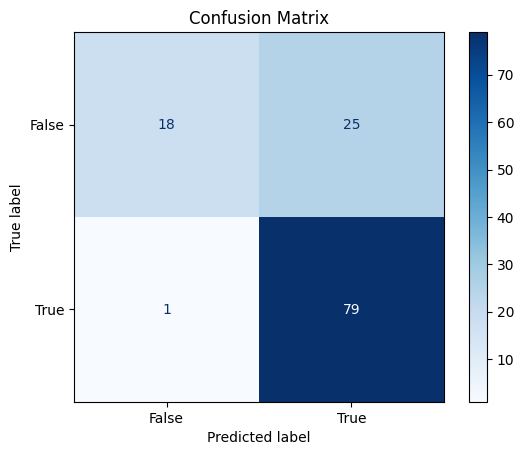

In [19]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### which features most influenced the prediction

In [20]:
# Create a dataframe of feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(importance_df.head(10))  # Top 10 features

                     Feature  Coefficient
4             Credit_History     3.346985
595         Loan_ID_LP002931    -0.773300
619              Married_Yes     0.768032
517         Loan_ID_LP002648    -0.753536
463         Loan_ID_LP002473    -0.730662
330         Loan_ID_LP002068     0.727258
290         Loan_ID_LP001925    -0.726314
550         Loan_ID_LP002768    -0.725837
266         Loan_ID_LP001870    -0.725691
625  Property_Area_Semiurban     0.723603
